# Task 2 — Leaderboard Challenge: an Autoformer forecaster

AI651 · PA1 · Task 2

**Goal.** Forecast the next **168** values (`time_idx` 43657 … 43824) of an anonymised univariate
series with an **Autoformer**. The model must contain both Autoformer mechanisms:

1. **Series decomposition**: a moving-average trend/seasonal split, repeated inside every block.
2. **Auto-Correlation**: period-level dependency discovery. FFT delay scores pick the top-k lags,
   and the model aggregates time-shifted copies of the values instead of point-wise attention.

**Leaderboard score** = RMSE + α·P + β·E (P = trainable parameters, E = training epochs).
Fitting the four published top rows gives α ≈ 1.9e-9 and β ≈ 5e-4 (see the switches cell).
Both penalties are tiny next to RMSE differences, so accuracy dominates. The model is still
compact, and the number of epochs is chosen on validation.

**Structure of this notebook**

| Section | What happens |
|---|---|
| 0 | Setup, data loading, run switches |
| 1 | Exploratory analysis: level, heavy tail, memory, period recovery, external variables |
| 2 | Chronological validation protocol and naive baselines |
| 3 | Preprocessing and feature engineering |
| 4 | The Autoformer (written from scratch, with unit checks) |
| 5 | Training and evaluation utilities |
| 6 | Experiment 1: target transform × external-data ablation (incl. trailing-mean covariates), across seeds; epoch selection |
| 7 | Experiment 2: which external variables, and which portion (past vs future), carry signal |
| 8 | Experiment 3 (optional): model-size sweep for the P penalty |
| 9 | Final model, the 168 forecasts, and the declared P and E |

**Attribution.** The architecture follows Wu et al. (2021), *Autoformer: Decomposition
Transformers with Auto-Correlation for Long-Term Series Forecasting*, §§3.1–3.2, and the
structure of the authors' reference implementation (github.com/thuml/Autoformer: series_decomp,
AutoCorrelation, encoder/decoder layers, trend accumulation). Differences from that code:
delays are chosen **per example** (not shared across the batch during training), and the
aggregation reads `v[(t − τ) mod L]`, the same convention as Task 1's `aggregate_delays`. The
decomposition uses the same replicate-padded centred moving average as Task 1's
`SeriesDecomposition`.

In [3]:
import os, math, time, json, random, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F

# ---------------- run switches ----------------
QUICK = False            # True = a few-minute smoke run for debugging (NOT for the report)
RUN_SIZE_SWEEP = True    # Experiment 3: d_model sweep (adds ~9 short runs)
SEEDS = [0, 1, 2]        # every comparison is repeated over these seeds
FINAL_SEEDS = [0, 1, 2, 3, 4]   # submitted model = average of these seeds (P and E are summed)
# Leaderboard penalty weights estimated from the published top-4 rows (score − RMSE vs P, E):
# alpha ≈ 1.9e-9 per parameter, beta ≈ 5.0e-4 per epoch. Both are tiny next to RMSE differences,
# so accuracy dominates: a 5-seed ensemble of a ~25k-parameter model costs about +0.03.
ALPHA_HAT, BETA_HAT = 1.9e-9, 5.0e-4
def est_score(rmse, params, epochs):
    return rmse + ALPHA_HAT * params + BETA_HAT * epochs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = Path("results_task2"); OUT.mkdir(exist_ok=True)
FIG_NO = [0]

def save_fig(name):
    """Save the current figure as a numbered PDF + PNG for the report."""
    FIG_NO[0] += 1
    stem = OUT / f"fig{FIG_NO[0]:02d}_{name}"
    plt.savefig(f"{stem}.pdf", bbox_inches="tight"); plt.savefig(f"{stem}.png", dpi=130, bbox_inches="tight")
    plt.show()

def find_data_dir():
    for root in (Path("/kaggle/input"), Path("."), Path("..")):
        if root.exists():
            hits = sorted(root.rglob("student_train.csv"))
            if hits:
                return hits[0].parent
    raise FileNotFoundError("Attach the folder with student_train.csv, student_test.csv and "
                            "optional_external_data.csv (on Kaggle: as a dataset).")


train_df = pd.read_csv("/kaggle/input/datasets/usamaazam9/pa1-notebooks-and-dataset/Task2/Data/student_train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/usamaazam9/pa1-notebooks-and-dataset/Task2/Data/student_test.csv")
ext_df = pd.read_csv("/kaggle/input/datasets/usamaazam9/pa1-notebooks-and-dataset/Task2/Data/optional_external_data.csv")

y_raw = train_df["value"].to_numpy(dtype=np.float64)
N, H = len(y_raw), 168
T_ALL = len(ext_df)
assert N == 43656 and T_ALL == 43824 and len(test_df) == H
assert (train_df.time_idx.values == np.arange(1, N + 1)).all()
assert (test_df.time_idx.values == np.arange(N + 1, N + H + 1)).all()
assert (ext_df.time_idx.values == np.arange(1, T_ALL + 1)).all()
print(f"device={DEVICE}; data={DATA}; history N={N}; horizon H={H}; external rows={T_ALL}")

device=cuda; data=/kaggle/input/datasets/usamaazam9/pa1-notebooks-and-dataset/Task2/Data; history N=43656; horizon H=168; external rows=43824


## 1. Exploratory analysis

What we look for, and why it matters for the design:

* **Level and tail.** RMSE is dominated by large values, so heavy tails change the loss and the
  target transform.
* **Memory.** How fast does autocorrelation decay? That bounds what the target's own past can
  say about a 168-step horizon.
* **Period.** The timestamps are gone, so the period has to be recovered from the data. It then
  sets the moving-average width and the phase features.
* **External variables.** Is there a simultaneous relationship with the target? If so, the
  future part of the file (known over the horizon) is potentially valuable.

count    43656.0
mean        98.2
std         90.8
min          0.0
1%           6.0
25%         30.0
50%         73.0
75%        136.0
90%        218.0
99%        418.0
max        994.0
skewness = 1.83;  exact zeros = 2


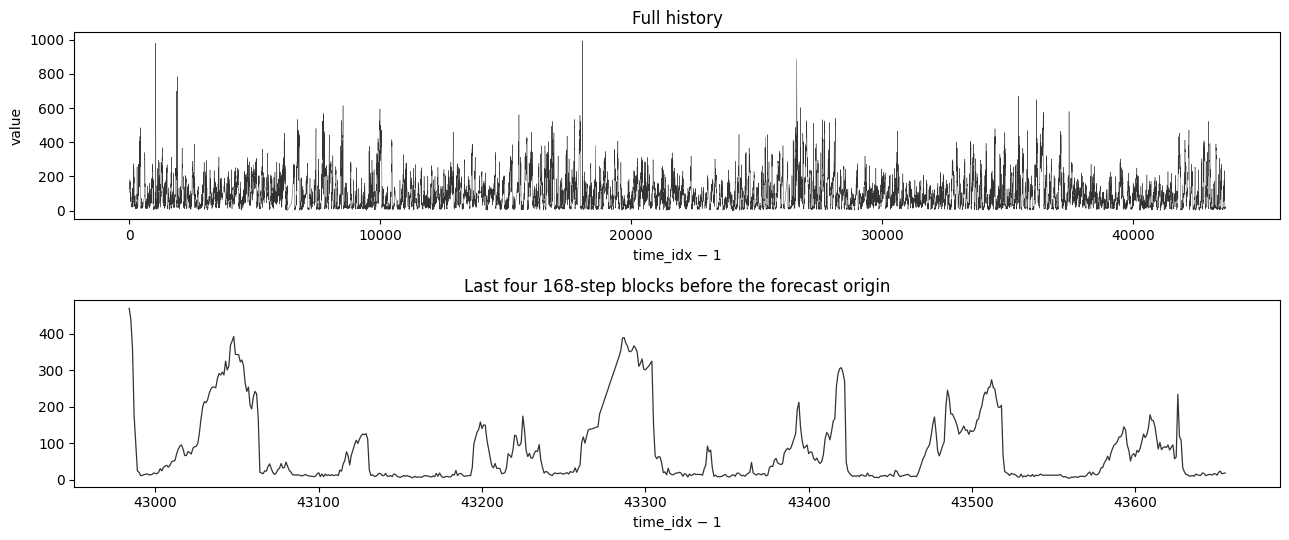

In [4]:
s = pd.Series(y_raw)
print(s.describe(percentiles=[.01, .25, .5, .75, .9, .99]).round(1).to_string())
print(f"skewness = {s.skew():.2f};  exact zeros = {(y_raw == 0).sum()}")

fig, ax = plt.subplots(2, 1, figsize=(13, 5.5))
ax[0].plot(y_raw, lw=0.3, color="#333"); ax[0].set(title="Full history", xlabel="time_idx − 1", ylabel="value")
ax[1].plot(np.arange(N - 4 * H, N), y_raw[-4 * H:], lw=0.9, color="#333")
ax[1].set(title="Last four 168-step blocks before the forecast origin", xlabel="time_idx − 1")
plt.tight_layout(); save_fig("series_overview")

autocorrelation at selected lags: {1: 0.966, 6: 0.749, 12: 0.57, 24: 0.401, 48: 0.158, 72: 0.077, 168: 0.028, 336: 0.048}
periodogram peak in 8–60 steps: 24;  ACF-of-differences peak: 24
largest periodogram peaks overall (period in steps): [269.5 183.4 386.3  24.  338.4 379.6]


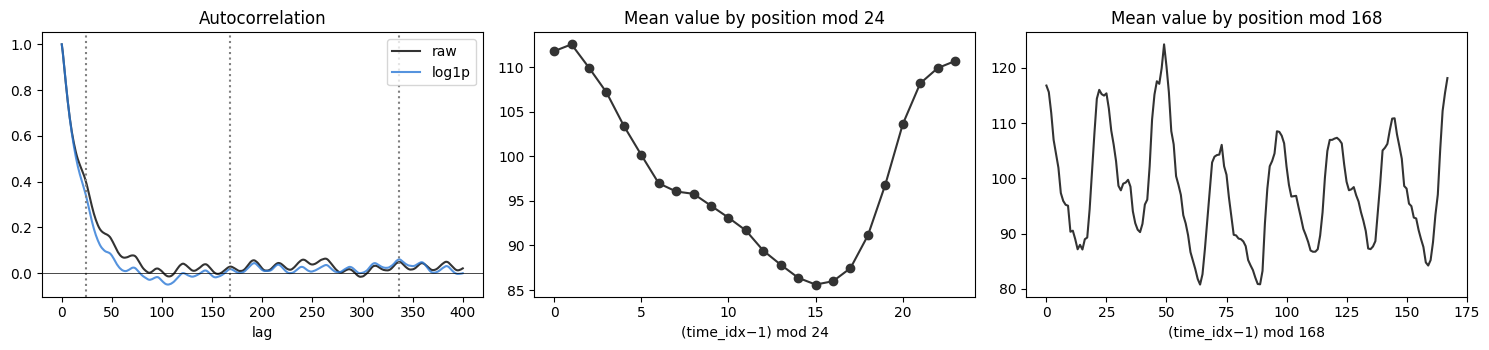

In [5]:
def acf(x, max_lag):
    x = np.asarray(x, float) - np.mean(x)
    spec = np.fft.rfft(x, n=2 * len(x))
    full = np.fft.irfft(spec * np.conj(spec))[: max_lag + 1]
    return full / full[0]

MAX_LAG = 400
r_raw, r_log = acf(y_raw, MAX_LAG), acf(np.log1p(y_raw), MAX_LAG)
print("autocorrelation at selected lags:",
      {k: round(float(r_raw[k]), 3) for k in (1, 6, 12, 24, 48, 72, 168, 336)})
# The raw ACF decays monotonically at short lags (strong persistence), so its maximum on a lag
# range is just the smallest lag. Recover the period two other ways instead:
#   (1) periodogram of log1p(value), peak among periods 8–60 steps;
#   (2) ACF of first differences (removes persistence), peak among lags 8–60.
z = np.log1p(y_raw) - np.log1p(y_raw).mean()
power = np.abs(np.fft.rfft(z)) ** 2
freqs = np.fft.rfftfreq(len(z))
band = (freqs >= 1 / 60) & (freqs <= 1 / 8)
PERIOD = int(round(1 / freqs[band][np.argmax(power[band])]))
r_diff = acf(np.diff(z), 100)
lags = np.arange(8, 61)
period_acf = int(lags[np.argmax(r_diff[lags])])
print(f"periodogram peak in 8–60 steps: {PERIOD};  ACF-of-differences peak: {period_acf}")
assert PERIOD == period_acf, "the two period estimates disagree: inspect the plots before continuing"
wide = (freqs > 1 / 400) & (freqs < 1 / 4)
top = np.argsort(power[wide])[::-1][:6]
print("largest periodogram peaks overall (period in steps):", np.round(1 / freqs[wide][top], 1))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(r_raw, label="raw", color="#333"); ax[0].plot(r_log, label="log1p", color="#2a78d6", alpha=.8)
for k in (24, 168, 336): ax[0].axvline(k, ls=":", color="grey")
ax[0].axhline(0, color="k", lw=.5); ax[0].set(title="Autocorrelation", xlabel="lag"); ax[0].legend()
prof24 = s.groupby(np.arange(N) % PERIOD).mean()
ax[1].plot(prof24.index, prof24.values, marker="o", color="#333")
ax[1].set(title=f"Mean value by position mod {PERIOD}", xlabel=f"(time_idx−1) mod {PERIOD}")
prof168 = s.groupby(np.arange(N) % 168).mean()
ax[2].plot(prof168.index, prof168.values, color="#333"); ax[2].set(title="Mean value by position mod 168", xlabel="(time_idx−1) mod 168")
plt.tight_layout(); save_fig("memory_and_period")

,corr with value,corr with log1p(value),x(t-24) vs y(t),x(t-6) vs y(t),x(t+0) vs y(t),x(t+6) vs y(t),x(t+24) vs y(t)
feature_A,0.169,0.308,0.101,0.244,0.309,0.283,0.193
feature_B,-0.088,0.019,0.002,0.049,0.019,0.058,0.044
feature_C,-0.048,-0.159,0.023,-0.128,-0.158,-0.172,-0.100
feature_D,-0.245,-0.348,-0.153,-0.302,-0.348,-0.308,-0.124
feature_E,0.019,0.032,-0.018,0.035,0.032,0.029,0.035
feature_F,-0.050,-0.049,-0.071,-0.069,-0.049,0.001,0.063
feature_G,-0.033,-0.064,-0.021,-0.070,-0.064,-0.033,0.017
feature_H,-0.212,-0.346,-0.215,-0.432,-0.346,-0.190,-0.060
feature_I,0.097,0.226,0.140,0.312,0.225,0.119,0.022
feature_J,0.154,0.182,0.099,0.183,0.182,0.104,0.029


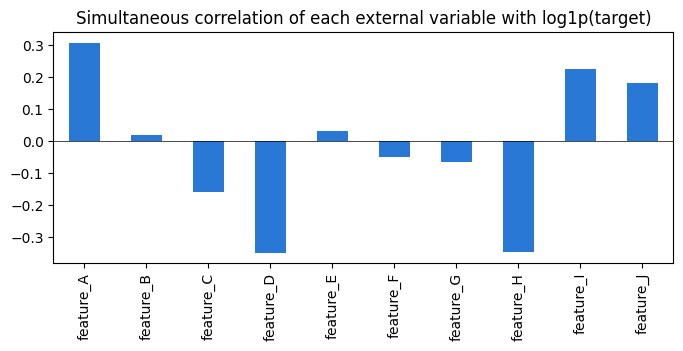

In [6]:
CONT = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F"]
BIN = ["feature_G", "feature_H", "feature_I", "feature_J"]
EXT = CONT + BIN
assert (ext_df[BIN].sum(axis=1) == 1).all(), "binary indicators should be mutually exclusive"
hist = ext_df.iloc[:N]
corr = pd.DataFrame({
    "corr with value": [np.corrcoef(hist[c], y_raw)[0, 1] for c in EXT],
    "corr with log1p(value)": [np.corrcoef(hist[c], np.log1p(y_raw))[0, 1] for c in EXT],
}, index=EXT)
# lead/lag check: correlation of the variable at time t+k with log1p(target) at time t
for k in (-24, -6, 0, 6, 24):
    corr[f"x(t{k:+d}) vs y(t)"] = [np.corrcoef(np.roll(hist[c].values, -k)[48:-48], np.log1p(y_raw)[48:-48])[0, 1] for c in EXT]
display(corr.round(3))
corr.round(4).to_csv(OUT / "external_correlations.csv")

corr["corr with log1p(value)"].plot.bar(figsize=(8, 3), color="#2a78d6")
plt.axhline(0, color="k", lw=.5); plt.title("Simultaneous correlation of each external variable with log1p(target)")
save_fig("external_correlations")

## 2. Validation protocol and baselines

The leaderboard scores **one** 168-step block, which is a noisy sample, and we only get five
submissions. Every decision here is therefore made on a **chronological rolling-origin**
estimate built from many blocks:

```
|──────────────── train ────────────────|──── evaluation: 26 non-overlapping 168-step blocks ────|
0                                   eval_start                                                 N
```

* **train**: fits weights and all preprocessing statistics (scalers).
* **evaluation**: 26 blocks (about half a year). Configurations **and the number of training
  epochs** are chosen here, always as the mean over blocks and over seeds, with block-level
  paired differences.

Why no separate early-stopping split? A first check showed that an 8-week early-stopping
window disagreed with the 26-block evaluation about when to stop, because 8 weeks is too
noisy. The number of epochs is therefore treated as a hyper-parameter: every run records its
evaluation RMSE after each epoch, and the epoch count with the best mean over seeds is used,
fixed, for the final fit on all data.

**Naive baselines** show how much of the 168-step horizon the target's own past can explain.

In [7]:
N_EVAL_BLOCKS = 26
EVAL_START = N - N_EVAL_BLOCKS * H
EVAL_ORIGINS = EVAL_START + H * np.arange(N_EVAL_BLOCKS)       # 0-based index of first forecast step
print(f"train targets [0, {EVAL_START}) · evaluation blocks [{EVAL_START}, {N})")

def smape(y, p):
    den = np.abs(y) + np.abs(p)
    return 100 * np.mean(np.where(den == 0, 0.0, 2 * np.abs(p - y) / np.where(den == 0, 1, den)))

def block_metrics(pred, origins, tag):
    rows = []
    for b, o in enumerate(origins):
        yt, pt = y_raw[o:o + H], pred[b]
        rows.append({**tag, "block": b, "RMSE": float(np.sqrt(np.mean((pt - yt) ** 2))),
                     "MAE": float(np.mean(np.abs(pt - yt))), "sMAPE": smape(yt, pt)})
    return rows

def baseline_forecasts(origins):
    out = {}
    out["persistence (last value)"] = np.stack([np.full(H, y_raw[o - 1]) for o in origins])
    out[f"seasonal naive ({PERIOD})"] = np.stack([np.resize(y_raw[o - PERIOD:o], H) for o in origins])
    out["seasonal naive (168)"] = np.stack([y_raw[o - H:o] for o in origins])
    out["mean of last 168"] = np.stack([np.full(H, y_raw[o - H:o].mean()) for o in origins])
    out["mean of last 24"] = np.stack([np.full(H, y_raw[o - 24:o].mean()) for o in origins])
    return out

BASE_PRED = baseline_forecasts(EVAL_ORIGINS)
base_rows = []
for name, p in BASE_PRED.items():
    base_rows += block_metrics(p, EVAL_ORIGINS, {"model": name})
baselines = pd.DataFrame(base_rows).groupby("model")[["RMSE", "MAE", "sMAPE"]].agg(["mean", "std"])
display(baselines.round(2))
baselines.round(3).to_csv(OUT / "baselines.csv")
BEST_BASELINE = baselines[("RMSE", "mean")].idxmin()
BEST_BASELINE_RMSE = baselines[("RMSE", "mean")].min()
print(f"best naive baseline on the evaluation blocks: {BEST_BASELINE} (RMSE {BEST_BASELINE_RMSE:.2f})")

train targets [0, 39288) · evaluation blocks [39288, 43656)


RMSE           MAE         sMAPE       
                            mean    std   mean    std   mean    std
model                                                              
mean of last 168           82.80  37.08  68.21  31.50  79.48  21.48
mean of last 24            96.95  55.54  78.58  47.63  88.04  23.51
persistence (last value)  115.35  92.10  95.54  87.35  88.31  24.29
seasonal naive (168)      113.06  52.23  89.69  42.10  97.31  21.51
seasonal naive (24)       106.63  58.26  84.52  49.27  94.22  22.78

best naive baseline on the evaluation blocks: mean of last 168 (RMSE 82.80)


## 3. Preprocessing and feature engineering

**Target.** Two options, compared in Experiment 1:
* `log1p`: compresses the heavy right tail and stabilises training. Back-transforming the mean
  of log values gives a median-like forecast, which can under-predict the mean and hurt RMSE.
* `none`: standardised raw values. This matches the RMSE objective directly, but the spikes
  dominate the gradient.

In both cases the transformed target is standardised with the **train-region** mean and std.
Forecasts are mapped back and clipped at 0, since the target is non-negative.

**External variables** (all 43,824 rows; the last 168 are known over the horizon):
* continuous A–F: D, E and F are non-negative and highly skewed, so they get `log1p`. All six
  are then standardised with train-region statistics.
* binary G–J (one-hot, mutually exclusive): used as they are.

**Phase features.** sin/cos of 2π·t/PERIOD and 2π·t/168, derived only from `time_idx` and the
recovered period. They stand in for the missing calendar features and are known for every
future step. They are kept the same in all external-data variants, so that ablation isolates
the external file.

**Where external data enters (the `external` switch):**

| mode | encoder covariates (past window) | decoder covariates (label part + 168 future steps) |
|---|---|---|
| `none` | phase | phase |
| `past` | phase + external (past only) | phase |
| `full` | phase + external (past) | phase + external (**including the known future**) |
| `full+roll` | as `full`, plus trailing 6/24/72-step means of every variable | as `full`, plus the same trailing means |

In [11]:
ROLL_WINDOWS = (6, 24, 72)

def build_covariates(train_end, use_phase=True, rolling=False):
    """Phase and external covariate arrays for all T_ALL steps; statistics from [0, train_end).
    Column layout of the external block: the 10 variables, then (if rolling) the 10 trailing
    means for each window in ROLL_WINDOWS, so variable j sits at columns j, j+10, j+20, ..."""
    ext = ext_df[EXT].astype(float).copy()
    for c in ("feature_D", "feature_E", "feature_F"):
        ext[c] = np.log1p(ext[c].clip(lower=0))
    blocks = [ext]
    if rolling:   # trailing means use only values at or before t; the file covers the horizon too
        for w in ROLL_WINDOWS:
            blocks.append(ext.rolling(w, min_periods=1).mean().add_suffix(f"_mean{w}"))
    ext = pd.concat(blocks, axis=1)
    binary = [c for c in ext.columns if c in BIN]            # raw one-hot columns stay 0/1
    scale = [c for c in ext.columns if c not in binary]
    mu, sd = ext.iloc[:train_end][scale].mean(), ext.iloc[:train_end][scale].std().replace(0, 1)
    ext[scale] = (ext[scale] - mu) / sd
    t = np.arange(T_ALL, dtype=float)
    phase = np.stack([f(2 * np.pi * t / p) for p in (PERIOD, 168) for f in (np.sin, np.cos)], 1)
    if not use_phase:
        phase = phase[:, :0]
    fill = ext.iloc[:train_end].mean().to_numpy()   # neutral values used by the occlusion study
    return phase.astype(np.float32), ext.to_numpy(np.float32), fill.astype(np.float32)

class TargetScaler:
    def __init__(self, kind, train_end):
        self.kind = kind
        z = self._fwd(y_raw[:train_end])
        self.mu, self.sd = float(z.mean()), float(z.std())
    def _fwd(self, y):
        return np.log1p(y) if self.kind == "log1p" else np.asarray(y, float)
    def transform(self, y):
        return (self._fwd(y) - self.mu) / self.sd
    def inverse(self, z):
        v = np.asarray(z, float) * self.sd + self.mu
        v = np.expm1(v) if self.kind == "log1p" else v
        return np.clip(v, 0, None)

class Batcher:
    """Builds (x_enc, mark_enc, mark_dec, target) batches by indexing GPU-resident arrays."""
    def __init__(self, cfg, train_end):
        self.cfg = cfg
        self.scaler = TargetScaler(cfg["target_transform"], train_end)
        y_full = np.zeros(T_ALL, np.float32)
        y_full[:N] = self.scaler.transform(y_raw)          # unknown future stays 0 and is never an input
        phase, ext, fill = build_covariates(train_end, cfg["use_phase"], cfg["rolling"])
        mode = cfg["external"]
        enc = [phase] + ([ext] if mode in ("past", "full") else [])
        dec = [phase] + ([ext] if mode == "full" else [])
        self.n_phase, self.n_ext = phase.shape[1], ext.shape[1]
        self.enc_uses_ext, self.dec_uses_ext = mode in ("past", "full"), mode == "full"
        to = lambda a: torch.tensor(a, device=DEVICE)
        self.y = to(y_full)
        self.m_enc = to(np.concatenate(enc, 1))
        self.m_dec = to(np.concatenate(dec, 1))
        self.fill = to(fill)
        L, lab, P = cfg["seq_len"], cfg["label_len"], cfg["pred_len"]
        self.r_enc = torch.arange(-L, 0, device=DEVICE)
        self.r_dec = torch.arange(-lab, P, device=DEVICE)
        self.r_tgt = torch.arange(0, P, device=DEVICE)

    def get(self, origins, occlude=None):
        o = torch.as_tensor(np.asarray(origins), device=DEVICE).long()[:, None]
        ie, idd = o + self.r_enc, o + self.r_dec
        x_enc = self.y[ie].unsqueeze(-1)
        m_enc, m_dec = self.m_enc[ie], self.m_dec[idd]
        if occlude is not None:                    # replace chosen external columns by train means
            m_enc, m_dec = m_enc.clone(), m_dec.clone()
            variables, part = occlude
            cols = [j + len(EXT) * k for j in variables for k in range(self.n_ext // len(EXT))]
            for c in cols:
                v = self.fill[c]
                if self.enc_uses_ext and part in ("all", "past"):
                    m_enc[..., self.n_phase + c] = v
                if self.dec_uses_ext:
                    lab = self.cfg["label_len"]
                    if part in ("all", "past"):
                        m_dec[:, :lab, self.n_phase + c] = v
                    if part in ("all", "future"):
                        m_dec[:, lab:, self.n_phase + c] = v
        target = self.y[o + self.r_tgt]
        return x_enc, m_enc, m_dec, target

## 4. The Autoformer

```
x_enc ─► decomp ─► seasonal_init (last label_len + zeros)  ─► dec-embedding ─┐
  │           └──► trend_init   (last label_len + mean(x_enc)) ──────────────┼─► trend accumulation
  └─► enc-embedding ─► [Encoder: Auto-Correlation → decomp → FFN → decomp] ─► cross ─► [Decoder:
       self Auto-Correlation → decomp → cross Auto-Correlation → decomp → FFN → decomp;
       each decomp's trend is projected and added to the trend] ─► seasonal + trend ─► 168 forecasts
```

* **Series decomposition** (Eq. 1 of the paper): replicate-padded centred moving average. It is
  applied to the input and **after every sub-layer** of every encoder and decoder layer
  (progressive decomposition). The decoder accumulates the extracted trends.
* **Auto-Correlation** (Eqs. 5–6): R(τ) = Σ_t q_t k_{(t−τ) mod L} for all τ at once via FFT,
  averaged over heads and channels. Keep the top k = ⌊factor·ln L⌋ delays, softmax their scores,
  and aggregate `v[(t − τ_j) mod L]` with those weights.
* **Embeddings**: a value embedding (circular Conv1d, kernel 3), plus a linear embedding of the
  covariates standing in for the paper's timestamp embedding. There is no positional encoding,
  as in the paper.

In [12]:
class SeriesDecomp(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        assert kernel % 2 == 1, "moving-average width must be odd"
        self.kernel = kernel
    def forward(self, x):                                     # x [B, L, C]
        r = self.kernel // 2
        if r == 0:
            return x - x, x
        padded = torch.cat([x[:, :1].expand(-1, r, -1), x, x[:, -1:].expand(-1, r, -1)], 1)
        trend = F.avg_pool1d(padded.transpose(1, 2), self.kernel, stride=1).transpose(1, 2)
        return x - trend, trend                               # (seasonal, trend)

class SeasonalLayerNorm(nn.Module):
    """Autoformer's my_Layernorm: LayerNorm, then remove the per-series mean over time."""
    def __init__(self, d):
        super().__init__(); self.norm = nn.LayerNorm(d)
    def forward(self, x):
        x = self.norm(x)
        return x - x.mean(1, keepdim=True)

def delay_scores(q, k):
    """q, k: [B, heads, E, L] -> R(tau) averaged over heads and E: [B, L]."""
    L = q.shape[-1]
    spec = torch.fft.rfft(q.float(), dim=-1) * torch.conj(torch.fft.rfft(k.float(), dim=-1))
    return torch.fft.irfft(spec, n=L, dim=-1).mean((1, 2))

def aggregate_delays(v, delays, weights):
    """v: [B, heads, D, L]; delays, weights: [B, K] -> sum_j w_j * v[(t - tau_j) mod L]."""
    B, h, D, L = v.shape
    K = delays.shape[1]
    t = torch.arange(L, device=v.device)
    idx = (t.view(1, 1, L) - delays.view(B, K, 1)) % L
    idx = idx.view(B, K, 1, 1, L).expand(-1, -1, h, D, -1)
    shifted = torch.gather(v.unsqueeze(1).expand(-1, K, -1, -1, -1), -1, idx)
    return (weights.view(B, K, 1, 1, 1) * shifted).sum(1)

class AutoCorrelation(nn.Module):
    def __init__(self, factor=1):
        super().__init__(); self.factor = factor
        self.last_delays = None
    def forward(self, q, k, v):                               # [B, L, h, E], [B, S, h, E], [B, S, h, D]
        B, L, h, E = q.shape
        S = k.shape[1]
        if L > S:                                             # align key/value length to query length
            pad = torch.zeros_like(q[:, : L - S])
            k = torch.cat([k, pad], 1); v = torch.cat([v, pad[..., : v.shape[-1]]], 1)
        else:
            k, v = k[:, :L], v[:, :L]
        scores = delay_scores(q.permute(0, 2, 3, 1), k.permute(0, 2, 3, 1))   # [B, L]
        top_k = max(1, int(self.factor * math.log(L)))
        w, delays = torch.topk(scores, top_k, dim=-1)                          # per example
        self.last_delays = delays.detach()
        w = torch.softmax(w, dim=-1).to(v.dtype)
        out = aggregate_delays(v.permute(0, 2, 3, 1), delays, w)               # [B, h, D, L]
        return out.permute(0, 3, 1, 2)                                         # [B, L, h, D]

class AutoCorrelationLayer(nn.Module):
    def __init__(self, d_model, n_heads, factor):
        super().__init__()
        self.h = n_heads
        self.q, self.k, self.v, self.o = (nn.Linear(d_model, d_model) for _ in range(4))
        self.inner = AutoCorrelation(factor)
    def forward(self, xq, xk, xv):
        B, L, d = xq.shape; S = xk.shape[1]
        q = self.q(xq).view(B, L, self.h, -1)
        k = self.k(xk).view(B, S, self.h, -1)
        v = self.v(xv).view(B, S, self.h, -1)
        return self.o(self.inner(q, k, v).reshape(B, L, d))

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.c1 = nn.Conv1d(d_model, d_ff, 1, bias=False)
        self.c2 = nn.Conv1d(d_ff, d_model, 1, bias=False)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        y = self.drop(F.gelu(self.c1(x.transpose(1, 2))))
        return self.drop(self.c2(y).transpose(1, 2))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, kernel, factor, dropout):
        super().__init__()
        self.attn = AutoCorrelationLayer(d_model, n_heads, factor)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.d1, self.d2 = SeriesDecomp(kernel), SeriesDecomp(kernel)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x, _ = self.d1(x + self.drop(self.attn(x, x, x)))
        x, _ = self.d2(x + self.ff(x))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, kernel, factor, dropout, c_out):
        super().__init__()
        self.self_attn = AutoCorrelationLayer(d_model, n_heads, factor)
        self.cross_attn = AutoCorrelationLayer(d_model, n_heads, factor)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.d1, self.d2, self.d3 = SeriesDecomp(kernel), SeriesDecomp(kernel), SeriesDecomp(kernel)
        self.drop = nn.Dropout(dropout)
        self.trend_proj = nn.Conv1d(d_model, c_out, 3, padding=1, padding_mode="circular", bias=False)
    def forward(self, x, cross):
        x, t1 = self.d1(x + self.drop(self.self_attn(x, x, x)))
        x, t2 = self.d2(x + self.drop(self.cross_attn(x, cross, cross)))
        x, t3 = self.d3(x + self.ff(x))
        trend = self.trend_proj((t1 + t2 + t3).transpose(1, 2)).transpose(1, 2)
        return x, trend

class Embedding(nn.Module):
    def __init__(self, c_in, mark_dim, d_model, dropout):
        super().__init__()
        self.value = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.mark = nn.Linear(mark_dim, d_model, bias=False) if mark_dim > 0 else None
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mark):
        e = self.value(x.transpose(1, 2)).transpose(1, 2)
        if self.mark is not None:
            e = e + self.mark(mark)
        return self.drop(e)

class Autoformer(nn.Module):
    def __init__(self, cfg, enc_mark_dim, dec_mark_dim, c_in=1, c_out=1):
        super().__init__()
        self.cfg = cfg
        d, h, ff, k, fac, dr = (cfg[x] for x in ("d_model", "n_heads", "d_ff", "moving_avg", "factor", "dropout"))
        self.decomp = SeriesDecomp(k)
        self.enc_emb = Embedding(c_in, enc_mark_dim, d, dr)
        self.dec_emb = Embedding(c_in, dec_mark_dim, d, dr)
        self.encoder = nn.ModuleList([EncoderLayer(d, h, ff, k, fac, dr) for _ in range(cfg["e_layers"])])
        self.enc_norm = SeasonalLayerNorm(d)
        self.decoder = nn.ModuleList([DecoderLayer(d, h, ff, k, fac, dr, c_out) for _ in range(cfg["d_layers"])])
        self.dec_norm = SeasonalLayerNorm(d)
        self.proj = nn.Linear(d, c_out)

    def forward(self, x_enc, mark_enc, mark_dec):
        lab, P = self.cfg["label_len"], self.cfg["pred_len"]
        mean = x_enc.mean(1, keepdim=True).expand(-1, P, -1)
        zeros = torch.zeros_like(mean)
        seasonal_init, trend_init = self.decomp(x_enc)
        trend = torch.cat([trend_init[:, -lab:], mean], 1)
        seasonal = torch.cat([seasonal_init[:, -lab:], zeros], 1)
        enc = self.enc_emb(x_enc, mark_enc)
        for layer in self.encoder:
            enc = layer(enc)
        enc = self.enc_norm(enc)
        dec = self.dec_emb(seasonal, mark_dec)
        for layer in self.decoder:
            dec, t = layer(dec, enc)
            trend = trend + t
        out = self.proj(self.dec_norm(dec)) + trend
        return out[:, -P:, 0]                                  # [B, P]

def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Unit checks
These use the Task 1 worked examples, plus shape and gradient tests.

In [13]:
_ex = torch.tensor([1., 2., 3., 10., 5.]).view(1, 5, 1)
_s, _t = SeriesDecomp(3)(_ex)
assert torch.allclose(_t.flatten(), torch.tensor([4 / 3, 2., 5., 6., 20 / 3])) and torch.allclose(_s + _t, _ex)
_q = torch.tensor([1., 3., 1., 3.]).view(1, 1, 1, 4)
assert torch.allclose(delay_scores(_q - 2, _q - 2).flatten(), torch.tensor([4., -4., 4., -4.]))
_agg = aggregate_delays(torch.tensor([10., 20., 30., 40.]).view(1, 1, 1, 4), torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
assert torch.allclose(_agg.flatten(), torch.tensor([35., 15., 25., 25.])), "delay direction is wrong"
_cfg = dict(seq_len=48, label_len=24, pred_len=24, d_model=8, n_heads=2, d_ff=16, moving_avg=5,
            factor=1, dropout=0.0, e_layers=1, d_layers=1)
_m = Autoformer(_cfg, 3, 3)
_x = torch.randn(2, 48, 1, requires_grad=True)
_o = _m(_x, torch.randn(2, 48, 3), torch.randn(2, 48, 3))
assert _o.shape == (2, 24)
_o.sum().backward(); assert _x.grad is not None and torch.isfinite(_x.grad).all()
print("decomposition, delay-score, aggregation, shape and gradient checks passed")

decomposition, delay-score, aggregation, shape and gradient checks passed


## 5. Training and evaluation utilities

* **Loss**: MSE on the transformed, standardised target, averaged over all 168 steps. This is
  direct multi-step forecasting, so predictions are never fed back as inputs.
* **Optimiser**: Adam, learning rate multiplied by `lr_decay` after every epoch, gradient
  clipping at 1.0.
* **Training windows**: every `train_stride`-th forecast origin whose 168-step target lies
  entirely in the training region. Neighbouring windows overlap almost completely, so stride 4
  loses little information and gives short epochs, which makes the epoch count a fine-grained
  control.
* **Epoch selection**: after every epoch, the model forecasts the 26 evaluation blocks. The
  epoch count with the lowest RMSE (mean over seeds) is chosen per configuration. The final
  model is trained for exactly that many epochs, and E counts them all.

In [14]:
BASE_CFG = dict(
    seq_len=336, label_len=168, pred_len=H,
    d_model=32, n_heads=4, d_ff=64, e_layers=1, d_layers=1,
    moving_avg=PERIOD + 1 if PERIOD % 2 == 0 else PERIOD, factor=1, dropout=0.1,
    batch_size=128, lr=3e-4, lr_decay=0.85, max_epochs=15, train_stride=4, clip=1.0,
    target_transform="log1p", external="full", rolling=False, use_phase=True,
)
if QUICK:
    BASE_CFG.update(train_stride=32, max_epochs=3)
    SEEDS = SEEDS[:2]
    FINAL_SEEDS = FINAL_SEEDS[:2]
print(json.dumps(BASE_CFG, indent=1))

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def predict(model, batcher, origins, occlude=None, bs=256):
    model.eval()
    out = []
    for i in range(0, len(origins), bs):
        x, me, md, _ = batcher.get(origins[i:i + bs], occlude)
        out.append(model(x, me, md).float().cpu().numpy())
    return batcher.scaler.inverse(np.concatenate(out))        # original units, clipped at 0

def raw_rmse(pred, origins):
    tgt = np.stack([y_raw[o:o + H] for o in origins])
    return float(np.sqrt(np.mean((pred - tgt) ** 2)))

def train_model(cfg, seed, train_end, n_epochs, track=None, verbose=True):
    """Train for n_epochs on targets inside [0, train_end). If `track` (origins) is given,
    forecast them after every epoch and keep those forecasts plus a weight snapshot."""
    set_seed(seed)
    batcher = Batcher(cfg, train_end)                          # scalers see the training region only
    tr_orig = np.arange(cfg["seq_len"], train_end - H + 1, cfg["train_stride"])
    model = Autoformer(cfg, batcher.m_enc.shape[1], batcher.m_dec.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    rng = np.random.default_rng(seed)
    history, preds, states = [], [], []
    t0 = time.time()
    for epoch in range(n_epochs):
        for g in opt.param_groups:
            g["lr"] = cfg["lr"] * cfg["lr_decay"] ** epoch
        model.train()
        perm = rng.permutation(tr_orig)
        losses = []
        for i in range(0, len(perm), cfg["batch_size"]):
            x, me, md, y = batcher.get(perm[i:i + cfg["batch_size"]])
            loss = F.mse_loss(model(x, me, md), y)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["clip"]); opt.step()
            losses.append(loss.item())
        rec = {"epoch": epoch + 1, "train_loss": float(np.mean(losses))}
        if track is not None:
            p = predict(model, batcher, track)
            preds.append(p); rec["eval_RMSE"] = raw_rmse(p, track)
            states.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        history.append(rec)
        if verbose:
            print(f"    epoch {epoch + 1:2d}  train MSE {rec['train_loss']:.4f}"
                  + (f"  eval RMSE {rec['eval_RMSE']:8.3f}" if track is not None else ""))
    info = {"epochs_run": n_epochs, "params": n_params(model), "seconds": time.time() - t0,
            "history": history, "preds": preds, "states": states}
    return model, batcher, info

{
 "seq_len": 336,
 "label_len": 168,
 "pred_len": 168,
 "d_model": 32,
 "n_heads": 4,
 "d_ff": 64,
 "e_layers": 1,
 "d_layers": 1,
 "moving_avg": 25,
 "factor": 1,
 "dropout": 0.1,
 "batch_size": 128,
 "lr": 0.0003,
 "lr_decay": 0.85,
 "max_epochs": 15,
 "train_stride": 4,
 "clip": 1.0,
 "target_transform": "log1p",
 "external": "full",
 "rolling": false,
 "use_phase": true
}


## 6. Experiment 1: target transform × external-data ablation (multi-seed)

There are 2 target transforms × 4 external variants × len(SEEDS) seeds. The fourth variant,
`full+roll`, adds trailing means of every external variable over 6, 24 and 72 steps. The EDA
showed variables at t−6 correlate with the target more strongly than at t, so the recent
history of the covariates carries signal (accumulation and clearing). Trailing means are
computable at every future step, because the file covers the horizon.

This experiment **is** the required with/without ablation of the optional file. Every run
is scored on the same 26 evaluation blocks after every epoch.

In [15]:
EPOCH_ROWS, MODELS, INFOS, CONFIGS = [], {}, [], {}

def features_label(cfg):
    return cfg["external"] + ("+roll" if cfg["rolling"] else "")

def run(cfg, seed, label):
    print(f"[{label}] seed {seed}")
    CONFIGS[label] = cfg
    model, batcher, info = train_model(cfg, seed, EVAL_START, cfg["max_epochs"], track=EVAL_ORIGINS)
    tag = {"config": label, "seed": seed, "target_transform": cfg["target_transform"],
           "external": features_label(cfg), "d_model": cfg["d_model"], "e_layers": cfg["e_layers"]}
    for e, p in enumerate(info["preds"], 1):
        EPOCH_ROWS.extend(block_metrics(p, EVAL_ORIGINS, {**tag, "epoch": e}))
    INFOS.append({**tag, "params": info["params"], "seconds": info["seconds"]})
    MODELS[(label, seed)] = (model, batcher, info)
    best = min(info["history"], key=lambda r: r["eval_RMSE"])
    print(f"    -> params {info['params']:,}; best epoch {best['epoch']} (RMSE {best['eval_RMSE']:.2f}); {info['seconds']:.0f}s")

def best_epoch_table():
    """For each config: mean RMSE over seeds and blocks at every epoch -> choose the best epoch.
    Returns the block-level rows at that epoch and the per-config chosen epoch."""
    er = pd.DataFrame(EPOCH_ROWS)
    curve = er.groupby(["config", "epoch"])["RMSE"].mean().unstack("epoch")
    chosen = curve.idxmin(axis=1)
    rows = pd.concat([er[(er.config == c) & (er.epoch == e)] for c, e in chosen.items()])
    return rows, chosen, curve

for transform in ("log1p", "none"):
    for mode, rolling in (("none", False), ("past", False), ("full", False), ("full", True)):
        cfg = dict(BASE_CFG, target_transform=transform, external=mode, rolling=rolling)
        for seed in SEEDS:
            run(cfg, seed, f"{transform}|{features_label(cfg)}")

[log1p|none] seed 0
    epoch  1  train MSE 1.0958  eval RMSE   93.957
    epoch  2  train MSE 1.0736  eval RMSE   93.858
    epoch  3  train MSE 1.0685  eval RMSE   93.153
    epoch  4  train MSE 1.0632  eval RMSE   92.396
    epoch  5  train MSE 1.0597  eval RMSE   92.165
    epoch  6  train MSE 1.0582  eval RMSE   92.538
    epoch  7  train MSE 1.0565  eval RMSE   92.084
    epoch  8  train MSE 1.0554  eval RMSE   91.969
    epoch  9  train MSE 1.0549  eval RMSE   92.238
    epoch 10  train MSE 1.0541  eval RMSE   92.026
    epoch 11  train MSE 1.0537  eval RMSE   91.928
    epoch 12  train MSE 1.0524  eval RMSE   92.090
    epoch 13  train MSE 1.0530  eval RMSE   91.933
    epoch 14  train MSE 1.0527  eval RMSE   92.331
    epoch 15  train MSE 1.0523  eval RMSE   92.237
    -> params 21,569; best epoch 11 (RMSE 91.93); 36s
[log1p|none] seed 1
    epoch  1  train MSE 1.1225  eval RMSE   93.632
    epoch  2  train MSE 1.0786  eval RMSE   93.206
    epoch  3  train MSE 1.0730  eval RM

RMSE          MAE        sMAPE  \
                                             mean   std   mean   std   mean   
config          target_transform external                                     
log1p|full+roll log1p            full+roll  55.35  1.61  39.88  0.89  50.77   
none|full+roll  none             full+roll  61.44  1.07  48.99  1.67  67.17   
log1p|full      log1p            full       62.97  2.02  45.35  1.06  56.15   
none|full       none             full       65.39  1.76  53.71  2.73  70.74   
none|past       none             past       80.85  1.35  66.84  1.75  78.85   
none|none       none             none       81.22  0.81  67.90  0.53  79.27   
log1p|none      log1p            none       82.49  0.69  63.29  0.75  79.99   
log1p|past      log1p            past       83.13  0.39  63.86  0.15  80.73   

                                                     cost             
                                             std   params best_epoch  
config          target_transform external                             
log1p|full+roll log1p            full+roll  0.33  24129.0         15  
none|full+roll  none             full+roll  1.10  24129.0          3  
log1p|full      log1p            full       1.04  22209.0         12  
none|full       none             full       2.71  22209.0         11  
none|past       none             past       1.17  21889.0          4  
none|none       none             none       1.07  21569.0          4  
log1p|none      log1p            none       0.81  21569.0         10  
log1p|past      log1p            past       0.42  21889.0          2

best naive baseline: mean of last 168  RMSE 82.80


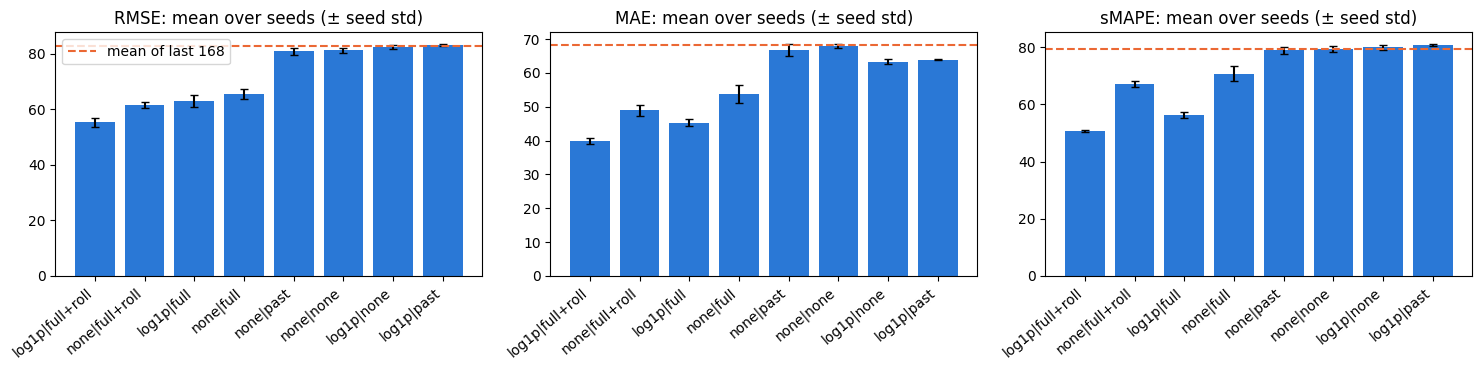

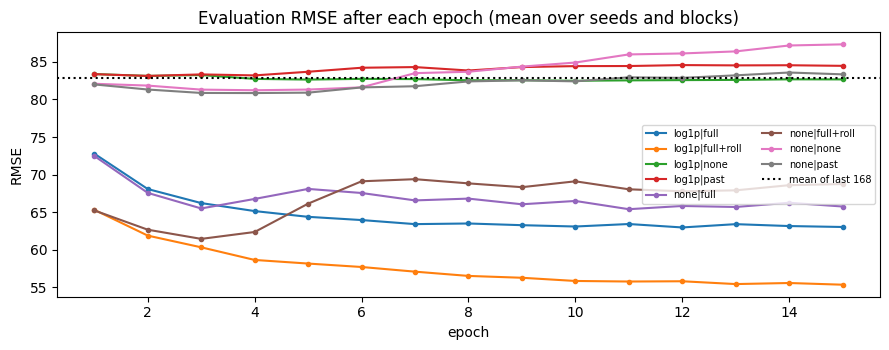

In [16]:
res, chosen_epoch, curve = best_epoch_table()
per_seed = res.groupby(["config", "target_transform", "external", "seed"])[["RMSE", "MAE", "sMAPE"]].mean().reset_index()
summary = per_seed.groupby(["config", "target_transform", "external"])[["RMSE", "MAE", "sMAPE"]].agg(["mean", "std"])
cost = pd.DataFrame(INFOS).groupby("config")[["params"]].mean().assign(best_epoch=chosen_epoch)
summary = summary.join(pd.concat({"cost": cost}, axis=1), on="config").sort_values(("RMSE", "mean"))
display(summary.round(2))
summary.round(3).to_csv(OUT / "exp1_transform_x_external.csv")
pd.DataFrame(EPOCH_ROWS).to_csv(OUT / "exp1_block_level_all_epochs.csv", index=False)
print(f"best naive baseline: {BEST_BASELINE}  RMSE {BEST_BASELINE_RMSE:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
order = summary.index.get_level_values(0)
for a, m in zip(ax, ("RMSE", "MAE", "sMAPE")):
    a.bar(range(len(order)), summary[(m, "mean")], yerr=summary[(m, "std")], color="#2a78d6", capsize=3)
    a.set_xticks(range(len(order))); a.set_xticklabels(order, rotation=40, ha="right")
    a.axhline(baselines.loc[BEST_BASELINE, (m, "mean")], color="#eb6834", ls="--", label=BEST_BASELINE)
    a.set_title(f"{m}: mean over seeds (± seed std)")
ax[0].legend()
plt.tight_layout(); save_fig("exp1_ablation")

fig, ax = plt.subplots(figsize=(9, 3.6))
for c in curve.index:
    ax.plot(curve.columns, curve.loc[c], marker="o", ms=3, label=c)
ax.axhline(BEST_BASELINE_RMSE, color="k", ls=":", label=BEST_BASELINE)
ax.set(title="Evaluation RMSE after each epoch (mean over seeds and blocks)", xlabel="epoch", ylabel="RMSE")
ax.legend(fontsize=7, ncol=2); plt.tight_layout(); save_fig("exp1_epoch_curves")

### Is the external-data effect real or noise?

This is a **paired** comparison. For every seed and every evaluation block, take
RMSE(variant A) − RMSE(variant B) under the same target transform, each at its chosen epoch.
Negative means A is better. The same blocks and seeds are compared, so block difficulty
cancels out. We report the mean difference, a standard error across blocks (after averaging
seeds), and the fraction of blocks that improved.

,transform,comparison,mean ΔRMSE,std error (blocks),blocks improved (%),per-seed mean Δ
0,log1p,full − none,-19.519,4.236,88.462,"[-20.8, -17.68, -20.08]"
1,log1p,past − none,0.643,0.223,30.769,"[1.83, 0.15, -0.05]"
2,log1p,full − past,-20.162,4.276,88.462,"[-22.63, -17.83, -20.03]"
3,log1p,full+roll − full,-7.618,2.317,80.769,"[-4.48, -8.87, -9.5]"
4,none,full − none,-15.827,4.219,76.923,"[-12.89, -17.58, -17.02]"
5,none,past − none,-0.373,1.179,46.154,"[1.13, 0.12, -2.37]"
6,none,full − past,-15.455,4.308,80.769,"[-14.02, -17.7, -14.65]"
7,none,full+roll − full,-3.950,1.854,65.385,"[-7.19, -2.19, -2.47]"


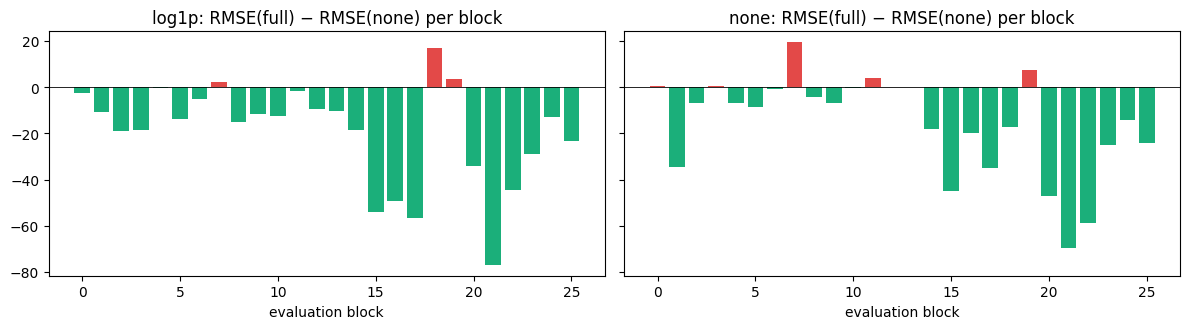

In [17]:
def paired(res, transform, a, b):
    pa = res[(res.target_transform == transform) & (res.external == a)].set_index(["seed", "block"])["RMSE"]
    pb = res[(res.target_transform == transform) & (res.external == b)].set_index(["seed", "block"])["RMSE"]
    d = (pa - pb).dropna()
    per_block = d.groupby("block").mean()
    return {"transform": transform, "comparison": f"{a} − {b}", "mean ΔRMSE": d.mean(),
            "std error (blocks)": per_block.std(ddof=1) / np.sqrt(len(per_block)),
            "blocks improved (%)": 100 * (per_block < 0).mean(),
            "per-seed mean Δ": [round(v, 2) for v in d.groupby("seed").mean().values]}, per_block

rows, blocks_for_plot = [], {}
for tr in ("log1p", "none"):
    for a, b in (("full", "none"), ("past", "none"), ("full", "past"), ("full+roll", "full")):
        r, pb = paired(res, tr, a, b); rows.append(r); blocks_for_plot[(tr, a, b)] = pb
paired_tab = pd.DataFrame(rows)
display(paired_tab.round(3))
paired_tab.to_csv(OUT / "exp1_paired_external.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for a, tr in zip(ax, ("log1p", "none")):
    pb = blocks_for_plot[(tr, "full", "none")]
    a.bar(pb.index, pb.values, color=np.where(pb.values < 0, "#1baf7a", "#e34948"))
    a.axhline(0, color="k", lw=.6); a.set(title=f"{tr}: RMSE(full) − RMSE(none) per block", xlabel="evaluation block")
plt.tight_layout(); save_fig("exp1_paired_blocks")

## 7. Experiment 2: which variables, and which portion, carry signal?

For each transform we take the better of the trained `full` / `full+roll` models, all seeds,
at the chosen epoch. At evaluation time a variable (including its trailing means, if present)
is replaced by its train-region mean (occlusion), with no retraining, and we measure how much
RMSE rises:

* **per variable**: each of the ten external variables, occluded in both past and future;
* **per portion**: every external variable occluded in the *past window only* vs over the
  *future horizon only*.

A large rise means the trained model relies on that input. Occlusion measures reliance, not
causation, so pair it with the retraining ablation in Experiment 1.

log1p: occlusion study on log1p|full+roll (epoch 15)
none: occlusion study on none|full+roll (epoch 3)


mean          std      
transform             log1p   none log1p  none
occluded                                      
ALL external, all     35.67  23.48  3.21  1.18
ALL external, future  36.31  28.32  2.56  4.09
ALL external, past     7.03   7.70  2.66  0.73
feature_A             22.06  18.45  2.62  4.88
feature_B             11.21  15.17  2.00  5.96
feature_C              1.56   2.58  1.60  1.16
feature_D              2.10   1.53  0.75  0.65
feature_E              0.23  -0.12  0.17  0.18
feature_F              2.05  -0.58  0.72  0.47
feature_G              2.79   1.62  3.41  0.44
feature_H              6.63   3.55  3.53  3.87
feature_I              1.36   0.97  0.93  1.36
feature_J              4.84   1.18  5.04  1.11

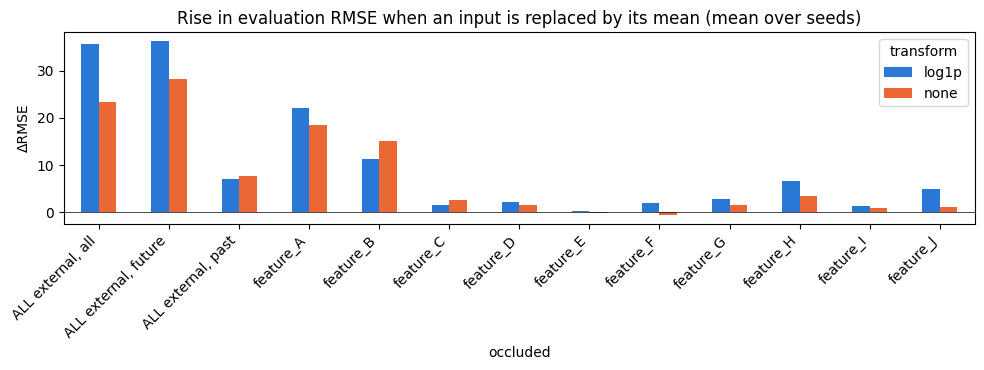

In [18]:
def model_at(label, seed, epoch):
    model, batcher, info = MODELS[(label, seed)]
    m = copy.deepcopy(model); m.load_state_dict(info["states"][epoch - 1])
    return m, batcher, info["preds"][epoch - 1]

imp_rows = []
for tr in ("log1p", "none"):
    occ_label = min([f"{tr}|full", f"{tr}|full+roll"], key=lambda l: res[res.config == l]["RMSE"].mean())
    print(f"{tr}: occlusion study on {occ_label} (epoch {chosen_epoch[occ_label]})")
    for seed in SEEDS:
        model, batcher, pred = model_at(occ_label, seed, chosen_epoch[occ_label])
        base = raw_rmse(pred, EVAL_ORIGINS)
        for j, name in enumerate(EXT):
            p = predict(model, batcher, EVAL_ORIGINS, occlude=([j], "all"))
            imp_rows.append({"transform": tr, "seed": seed, "occluded": name, "ΔRMSE": raw_rmse(p, EVAL_ORIGINS) - base})
        for part in ("past", "future", "all"):
            p = predict(model, batcher, EVAL_ORIGINS, occlude=(list(range(len(EXT))), part))
            imp_rows.append({"transform": tr, "seed": seed, "occluded": f"ALL external, {part}", "ΔRMSE": raw_rmse(p, EVAL_ORIGINS) - base})
imp = pd.DataFrame(imp_rows)
imp_tab = imp.groupby(["transform", "occluded"])["ΔRMSE"].agg(["mean", "std"]).unstack(0)
display(imp_tab.round(2))
imp_tab.round(3).to_csv(OUT / "exp2_occlusion.csv")

fig, ax = plt.subplots(figsize=(10, 3.8))
t = imp.groupby(["occluded", "transform"])["ΔRMSE"].mean().unstack()
t.plot.bar(ax=ax, color=["#2a78d6", "#eb6834"]); ax.axhline(0, color="k", lw=.5)
ax.set(title="Rise in evaluation RMSE when an input is replaced by its mean (mean over seeds)", ylabel="ΔRMSE")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); save_fig("exp2_occlusion")

## 8. Experiment 3 (optional): model size vs accuracy

The score penalises P, but the estimated α is tiny (about 2e-9 per parameter), so size only
matters if it changes RMSE. We take the best configuration from Experiment 1 and try
d_model ∈ {16, 64} with one layer, and d_model 64 with two encoder and two decoder layers
(d_ff = 2·d_model).

In [19]:
best_cfg_label = summary.index[0][0]
print("best configuration from Experiment 1:", best_cfg_label)
if RUN_SIZE_SWEEP and not QUICK:
    base = CONFIGS[best_cfg_label]
    for d, layers in ((16, 1), (64, 1), (64, 2)):     # d_model 32 / 1 layer was trained in Experiment 1
        cfg = dict(base, d_model=d, d_ff=2 * d, e_layers=layers, d_layers=layers)
        for seed in SEEDS:
            run(cfg, seed, f"{best_cfg_label}|d{d}x{layers}")
    res, chosen_epoch, curve = best_epoch_table()
    sub = res[res.config.str.startswith(best_cfg_label)]
    per_seed_sz = sub.groupby(["config", "seed"])[["RMSE", "MAE", "sMAPE"]].mean().reset_index()
    size_tab = per_seed_sz.groupby("config")[["RMSE", "MAE", "sMAPE"]].agg(["mean", "std"])
    size_cost = pd.DataFrame(INFOS).groupby("config")[["params", "seconds"]].mean().assign(best_epoch=chosen_epoch)
    size_tab = size_tab.join(pd.concat({"cost": size_cost}, axis=1))
    display(size_tab.round(2)); size_tab.round(3).to_csv(OUT / "exp3_model_size.csv")

best configuration from Experiment 1: log1p|full+roll
[log1p|full+roll|d16x1] seed 0
    epoch  1  train MSE 0.8981  eval RMSE   77.334
    epoch  2  train MSE 0.5939  eval RMSE   74.821
    epoch  3  train MSE 0.5394  eval RMSE   72.890
    epoch  4  train MSE 0.5136  eval RMSE   70.844
    epoch  5  train MSE 0.4981  eval RMSE   69.925
    epoch  6  train MSE 0.4868  eval RMSE   69.996
    epoch  7  train MSE 0.4785  eval RMSE   68.937
    epoch  8  train MSE 0.4724  eval RMSE   68.999
    epoch  9  train MSE 0.4668  eval RMSE   69.108
    epoch 10  train MSE 0.4631  eval RMSE   68.886
    epoch 11  train MSE 0.4595  eval RMSE   68.617
    epoch 12  train MSE 0.4569  eval RMSE   68.737
    epoch 13  train MSE 0.4553  eval RMSE   68.424
    epoch 14  train MSE 0.4533  eval RMSE   68.598
    epoch 15  train MSE 0.4513  eval RMSE   68.244
    -> params 6,945; best epoch 15 (RMSE 68.24); 21s
[log1p|full+roll|d16x1] seed 1
    epoch  1  train MSE 0.9681  eval RMSE   77.013
    epoch  2  t

RMSE          MAE        sMAPE            cost  \
                        mean   std   mean   std   mean   std    params   
config                                                                   
log1p|full+roll        55.35  1.61  39.88  0.89  50.77  0.33   24129.0   
log1p|full+roll|d16x1  61.39  1.85  43.55  1.14  53.47  0.99    6945.0   
log1p|full+roll|d64x1  57.18  0.51  41.22  1.52  52.34  1.95   89217.0   
log1p|full+roll|d64x2  57.38  1.72  40.94  0.96  51.36  1.20  172097.0   

                                          
                      seconds best_epoch  
config                                    
log1p|full+roll         36.74         15  
log1p|full+roll|d16x1   20.06         15  
log1p|full+roll|d64x1   71.36          8  
log1p|full+roll|d64x2  135.63          9

## 9. Final model and leaderboard forecasts

**Selection rule** (evaluation-block evidence only, fixed before any submission): take the
configuration with the lowest **estimated score** = mean evaluation RMSE over seeds
+ α̂·P·(ensemble size) + β̂·(chosen epochs)·(ensemble size), using the penalty weights
estimated from the published leaderboard rows. Because α̂ and β̂ are tiny, this is
effectively "lowest RMSE".

**Final fit.** For each seed in `FINAL_SEEDS` (default 5), train the selected configuration
on **all** observed data (targets up to time_idx 43656) for the chosen number of epochs.
Scalers are refitted on all data. Average the members' forecasts from origin
`time_idx = 43657`, using the last `seq_len` observed values and the external covariates,
including their known future values when the configuration uses them.

**Declared numbers.** P = `sum(p.numel() for p in model.parameters() if p.requires_grad)`
summed over every ensemble member. E = epochs run in the final fits, summed over members.
The experiment runs above only served selection and did not produce the submitted forecasts.

Caveat: choosing the epoch count on the same blocks that report the RMSE makes that RMSE
slightly optimistic. It is used for ranking configurations, not as a promise of the
leaderboard score.

In [20]:
res, chosen_epoch, curve = best_epoch_table()
k = len(FINAL_SEEDS)
cand = (res.groupby(["config", "seed"])["RMSE"].mean().groupby("config").agg(["mean", "std"])
        .join(pd.DataFrame(INFOS).groupby("config")[["params"]].mean()).assign(best_epoch=chosen_epoch))
cand["estimated score"] = [est_score(r, k * p, k * e) for r, p, e in zip(cand["mean"], cand["params"], cand["best_epoch"])]
cand = cand.sort_values("estimated score")
display(cand.round(3)); cand.round(4).to_csv(OUT / "selection_table.csv")
FINAL_LABEL = cand.index[0]
FINAL_EPOCHS = int(chosen_epoch[FINAL_LABEL])
final_cfg = dict(CONFIGS[FINAL_LABEL])
print(f"selected configuration: {FINAL_LABEL} trained for {FINAL_EPOCHS} epochs")
print(f"its evaluation RMSE {cand.loc[FINAL_LABEL, 'mean']:.2f} ± {cand.loc[FINAL_LABEL, 'std']:.2f} "
      f"vs best naive baseline {BEST_BASELINE_RMSE:.2f}")

# Evidence for ensembling: seed-averaged forecast vs single models on the same blocks.
sel_preds = np.stack([MODELS[(FINAL_LABEL, s)][2]["preds"][FINAL_EPOCHS - 1] for s in SEEDS])   # [seeds, blocks, H]
single = np.mean([raw_rmse(p, EVAL_ORIGINS) for p in sel_preds])
ens = raw_rmse(sel_preds.mean(0), EVAL_ORIGINS)
print(f"single-model RMSE (mean over seeds) {single:.2f}  vs  {len(SEEDS)}-seed ensemble RMSE {ens:.2f}")

,mean,std,params,best_epoch,estimated score
config,,,,,
log1p|full+roll,55.348,1.610,24129.0,15,55.386
log1p|full+roll|d64x1,57.179,0.505,89217.0,8,57.200
log1p|full+roll|d64x2,57.377,1.721,172097.0,9,57.401
log1p|full+roll|d16x1,61.389,1.855,6945.0,15,61.427
none|full+roll,61.445,1.073,24129.0,3,61.452
log1p|full,62.966,2.019,22209.0,12,62.996
none|full,65.395,1.760,22209.0,11,65.422
none|past,80.849,1.352,21889.0,4,80.860
none|none,81.222,0.806,21569.0,4,81.232


selected configuration: log1p|full+roll trained for 15 epochs
its evaluation RMSE 55.35 ± 1.61 vs best naive baseline 82.80
single-model RMSE (mean over seeds) 61.53  vs  3-seed ensemble RMSE 58.81


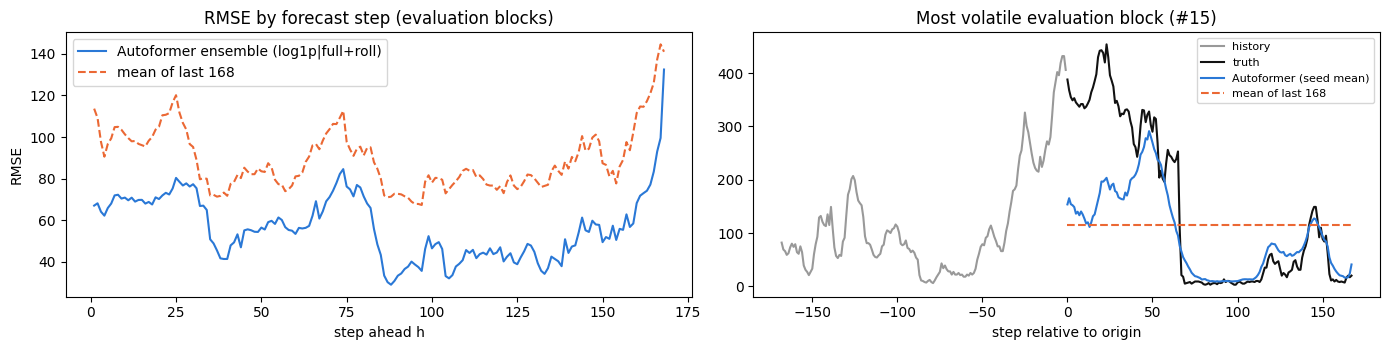

In [21]:
truth = np.stack([y_raw[o:o + H] for o in EVAL_ORIGINS])
h_rmse = np.sqrt(((sel_preds.mean(0) - truth) ** 2).mean(0))
b_rmse = np.sqrt(((BASE_PRED[BEST_BASELINE] - truth) ** 2).mean(0))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].plot(np.arange(1, H + 1), h_rmse, label=f"Autoformer ensemble ({FINAL_LABEL})", color="#2a78d6")
ax[0].plot(np.arange(1, H + 1), b_rmse, label=BEST_BASELINE, color="#eb6834", ls="--")
ax[0].set(title="RMSE by forecast step (evaluation blocks)", xlabel="step ahead h", ylabel="RMSE"); ax[0].legend()
b = int(np.argmax(truth.std(1)))
ax[1].plot(np.arange(-H, 0), y_raw[EVAL_ORIGINS[b] - H:EVAL_ORIGINS[b]], color="#999", label="history")
ax[1].plot(np.arange(H), truth[b], color="#111", label="truth")
ax[1].plot(np.arange(H), sel_preds[:, b].mean(0), color="#2a78d6", label="Autoformer (seed mean)")
ax[1].plot(np.arange(H), BASE_PRED[BEST_BASELINE][b], color="#eb6834", ls="--", label=BEST_BASELINE)
ax[1].set(title=f"Most volatile evaluation block (#{b})", xlabel="step relative to origin"); ax[1].legend(fontsize=8)
plt.tight_layout(); save_fig("horizon_and_example")

final fit on all observed data: log1p|full+roll, 15 epochs, seeds [0, 1, 2, 3, 4]
spread between ensemble members (mean std over steps): 10.2


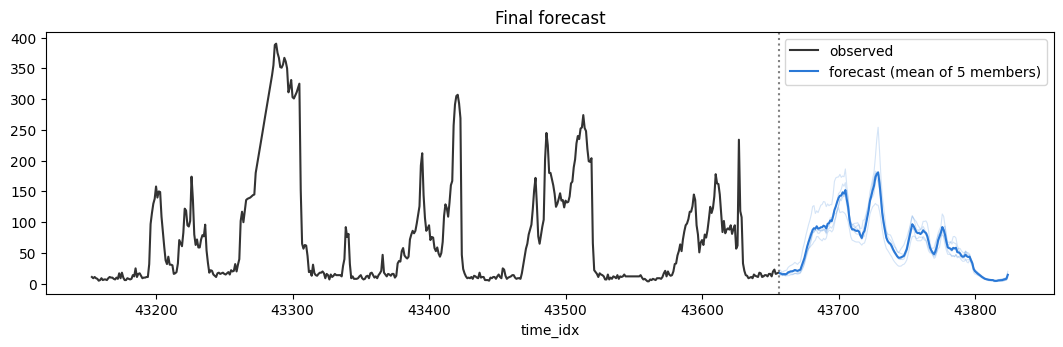


DECLARE ON THE LEADERBOARD:  P = 120,645 trainable parameters;  E = 75 epochs
(estimated penalty ≈ 0.0377)
168 values, first = time_idx 43657, last = time_idx 43824

Paste this into the predictions field:

17.1666, 16.3998, 15.3388, 15.8506, 15.4527, 16.1726, 18.3869, 19.2808, 20.1034, 20.2042, 21.0268, 22.3970, 21.6232, 20.8365, 21.9261, 22.7297, 29.0423, 35.0658, 41.8236, 51.3508, 60.0936, 67.5546, 74.1720, 80.3565, 87.4381, 90.2702, 89.3769, 93.3616, 89.7064, 89.9712, 91.7236, 91.8373, 94.3351, 93.2983, 89.9002, 97.4186, 98.5096, 102.9576, 101.6993, 109.5970, 119.8267, 125.6967, 133.1115, 139.3378, 143.0191, 143.3236, 148.4803, 146.4024, 152.1852, 137.0172, 125.1918, 104.3785, 93.0821, 88.3267, 88.5009, 86.9095, 85.8072, 86.2959, 84.7104, 78.6100, 74.3865, 82.1576, 85.9601, 96.1214, 107.8053, 118.6471, 134.4307, 142.6493, 151.8889, 159.4046, 173.0234, 178.3952, 181.0343, 163.6526, 140.6311, 115.4254, 99.6965, 86.7843, 75.0859, 69.6080, 66.6298, 64.9423, 60.9417, 55.7910, 51.7016, 4

In [22]:
print(f"final fit on all observed data: {FINAL_LABEL}, {FINAL_EPOCHS} epochs, seeds {FINAL_SEEDS}")
finals = [train_model(final_cfg, seed=s, train_end=N, n_epochs=FINAL_EPOCHS, verbose=False) for s in FINAL_SEEDS]
P_DECLARED = sum(n_params(m) for m, _, _ in finals)                         # summed over ensemble members
E_DECLARED = sum(info["epochs_run"] for _, _, info in finals)                # every epoch actually run
member_fc = np.stack([predict(m, b, np.array([N]))[0] for m, b, _ in finals])  # origin index N -> time_idx 43657
forecast = member_fc.mean(0)
assert forecast.shape == (H,) and np.isfinite(forecast).all()
print("spread between ensemble members (mean std over steps):", round(float(member_fc.std(0).mean()), 2))

sub = pd.DataFrame({"time_idx": test_df.time_idx.values, "value": forecast})
sub.to_csv(OUT / "submission_forecast.csv", index=False)
paste = ", ".join(f"{v:.4f}" for v in forecast)
(OUT / "leaderboard_paste.txt").write_text(paste)
meta = {"selected_config": FINAL_LABEL, "config": final_cfg, "epochs_per_member": FINAL_EPOCHS,
        "seeds": FINAL_SEEDS, "P_trainable_parameters": P_DECLARED, "E_training_epochs": E_DECLARED,
        "estimated_penalty": ALPHA_HAT * P_DECLARED + BETA_HAT * E_DECLARED,
        "first_time_idx": int(test_df.time_idx.iloc[0]), "last_time_idx": int(test_df.time_idx.iloc[-1])}
(OUT / "submission_meta.json").write_text(json.dumps(meta, indent=1))
for (m, _, _), sd in zip(finals, FINAL_SEEDS):
    torch.save(m.state_dict(), OUT / f"final_model_seed{sd}.pt")

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.plot(np.arange(N - 3 * H, N) + 1, y_raw[-3 * H:], color="#333", label="observed")
for mf in member_fc:
    ax.plot(test_df.time_idx.values, mf, color="#2a78d6", alpha=.2, lw=.8)
ax.plot(test_df.time_idx.values, forecast, color="#2a78d6", label=f"forecast (mean of {len(FINAL_SEEDS)} members)")
ax.axvline(N + 0.5, color="grey", ls=":"); ax.set(xlabel="time_idx", title="Final forecast"); ax.legend()
save_fig("final_forecast")

print(f"\nDECLARE ON THE LEADERBOARD:  P = {P_DECLARED:,} trainable parameters;  E = {E_DECLARED} epochs")
print(f"(estimated penalty ≈ {meta['estimated_penalty']:.4f})")
print(f"168 values, first = time_idx {meta['first_time_idx']}, last = time_idx {meta['last_time_idx']}")
print("\nPaste this into the predictions field:\n")
print(paste)

In [23]:
# Short text summary to copy into the report / share
print(json.dumps({
    "best naive baseline": {BEST_BASELINE: round(BEST_BASELINE_RMSE, 2)},
    "selected": FINAL_LABEL, "epochs": FINAL_EPOCHS,
    "eval RMSE mean±std over seeds": [round(cand.loc[FINAL_LABEL, "mean"], 2), round(cand.loc[FINAL_LABEL, "std"], 2)],
    "seed-ensemble eval RMSE": round(ens, 2),
    "P": P_DECLARED, "E": E_DECLARED,
}, indent=1))
print(summary.round(2).to_string())
print(paired_tab.round(3).to_string())
print(imp_tab.round(2).to_string())

{
 "best naive baseline": {
  "mean of last 168": 82.8
 },
 "selected": "log1p|full+roll",
 "epochs": 15,
 "eval RMSE mean\u00b1std over seeds": [
  55.35,
  1.61
 ],
 "seed-ensemble eval RMSE": 58.81,
 "P": 120645,
 "E": 75
}
                                             RMSE          MAE        sMAPE           cost           
                                             mean   std   mean   std   mean   std   params best_epoch
config          target_transform external                                                            
log1p|full+roll log1p            full+roll  55.35  1.61  39.88  0.89  50.77  0.33  24129.0         15
none|full+roll  none             full+roll  61.44  1.07  48.99  1.67  67.17  1.10  24129.0          3
log1p|full      log1p            full       62.97  2.02  45.35  1.06  56.15  1.04  22209.0         12
none|full       none             full       65.39  1.76  53.71  2.73  70.74  2.71  22209.0         11
none|past       none             past       80.85  1.35  66